# Imports

In [1]:
# Imports
import importlib
import os
import re
import glob
import time
import pickle
import shutil
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D


# setup

In [ ]:
# Setup 
PROJECT_ROOT = "C:/Project/" # change to your curent folder
PROJECT_DIR = os.path.join(PROJECT_ROOT, "TrAISformer")

if not os.path.exists(PROJECT_DIR):
    os.system(f"git clone https://github.com/CIA-Oceanix/TrAISformer.git {PROJECT_DIR}")
else:
    print("Repo already present, skipping clone.")

os.chdir(PROJECT_DIR)
import config_trAISformer as config
import models
import trainers
import datasets
import utils

print("Working directory:", os.getcwd())
print("GPU found:", torch.cuda.is_available())


Working directory: C:\Project\TrAISformer
GPU found: True


In [3]:
# needed helper functoins
def apply_device_fix():
    with open("config_trAISformer.py", "r") as f:
        content = f.read()
    if 'device = torch.device("cuda:0")' in content:
        content = content.replace(
            'device = torch.device("cuda:0")',
            'device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")'
        )
        with open("config_trAISformer.py", "w") as f:
            f.write(content)

def activate_config(source_path):
    cfg_path = os.path.join(PROJECT_DIR, "config_trAISformer.py")
    shutil.copy(source_path, cfg_path)
    apply_device_fix()
    importlib.reload(config)
    return config.Config()


In [4]:
# Look for needed folders and report what is found
target_names = {"northeast", "florida", "midatlantic"}
region_dirs = [
    d for d in sorted(os.listdir(PROJECT_ROOT))
    if os.path.isdir(os.path.join(PROJECT_ROOT, d)) and d.lower() in target_names
]
assert region_dirs, f"No region folders found in {PROJECT_ROOT} (looked for {sorted(target_names)})"

print(f"Found {len(region_dirs)} region folder(s):")
for i, name in enumerate(region_dirs):
    print(f"  [{i}] {name}")


Found 1 region folder(s):
  [0] Northeast


# Chose the desiered dataset
based on above outputs

In [ ]:
# Set up for your run
idx = 0          # Chose what data set you want based on the output above
Eval_hours = 5   # How long ot let things run (5 should be plenty to finish)


# Load in the needed files

In [16]:
# pull the needed info from the desiered folder
region_dir = os.path.join(PROJECT_ROOT, region_dirs[idx])
def find_one(ext):
    matches = glob.glob(os.path.join(region_dir, f"*.{ext}"))
    assert len(matches) == 1, f"Expected exactly one .{ext} file in {region_dir}, found {len(matches)}: {matches}"
    return matches[0]

pt_path = find_one("pt")
pkl_path = find_one("pkl")
cfg_path = region_dir + "/config.py"
# Print what is being used to confurm the right files are found
print("Using region folder:", region_dir)
print("Model:", pt_path)
print("Test data:", pkl_path)
print("Config:", cfg_path)


Using region folder: C:/Project/Northeast
Model: C:/Project/Northeast\model.pt
Test data: C:/Project/Northeast\CustemSel0_test.pkl
Config: C:/Project/Northeast/config.py


In [8]:
# load config and set up model
cf = activate_config(cfg_path)
cf.retrain = False
print(f"Active config: '{cf.dataset_name}', init_seqlen={cf.init_seqlen}, max_seqlen={cf.max_seqlen}")

model = models.TrAISformer(cf, partition_model=None)
model.load_state_dict(torch.load(pt_path, map_location=cf.device))
model = model.to(cf.device)


Active config: 'CustemSel0', init_seqlen=18, max_seqlen=120


In [9]:
# Same setup we have in the orginal model generatoin code
moving_threshold = 0.05
resampleMin = 10   

with open(pkl_path, "rb") as f:
    l_pred_errors = pickle.load(f)

for V in l_pred_errors:
    try:
        moving_idx = np.where(V["traj"][:, 2] > moving_threshold)[0][0]
    except IndexError:
        moving_idx = len(V["traj"]) - 1
    V["traj"] = V["traj"][moving_idx:, :]

Data = {"test": [x for x in l_pred_errors if not np.isnan(x["traj"]).any() and len(x["traj"]) > cf.min_seqlen]}
print(f"kept {len(Data['test'])} of {len(l_pred_errors)} tracks")

aisdataset = datasets.AISDataset(Data["test"], max_seqlen=cf.max_seqlen + 1, device=cf.device)
aisdls = {"test": torch.utils.data.DataLoader(aisdataset, batch_size=cf.batch_size, shuffle=False)}
print("Ready:", len(aisdls["test"].dataset), "test tracks")


kept 1759 of 4074 tracks
Ready: 1759 test tracks


## Test the model

In [10]:
# Set up kept same as in training - see notebooks for more info on each part
h = Eval_hours
timeSec = 3600 * h
init_seqlen = cf.init_seqlen
horizon_len = cf.max_seqlen - init_seqlen
max_seqlen = init_seqlen + horizon_len
n_samples_eval = 16 

start_time = time.time()
n_tracks_completed = 0
n_batches_completed = 0
time_limit_hit = False
total_tracks = len(aisdls["test"].dataset)
model.eval()
l_min_errors, l_mean_errors, l_masks = [], [], []
horizon_error_sum = torch.zeros(horizon_len)
horizon_mask_sum = torch.zeros(horizon_len)
final_step_errors = []
sample_times = []

v_ranges = torch.tensor([model.lat_range, model.lon_range, model.sog_range, 360.0]).to(cf.device)
v_roi_min = torch.tensor([model.lat_min, model.lon_min, 0.0, 0.0]).to(cf.device)

pbar = tqdm(enumerate(aisdls["test"]), total=len(aisdls["test"]))

with torch.no_grad():
    for it, (seqs, masks, seqlens, mmsis, time_starts) in pbar:
        elapsedT = time.time() - start_time
        if elapsedT > timeSec:
            time_limit_hit = True
            print("\n\n --- Testing stopped after", h, "hours")
            break

        seqs_init = seqs[:, :init_seqlen, :].to(cf.device)
        masks_b = masks[:, :max_seqlen].to(cf.device)
        batchsize = seqs.shape[0]
        error_ens = torch.zeros((batchsize, horizon_len, n_samples_eval)).to(cf.device)

        for i_sample in range(n_samples_eval):
            t0 = time.time()
            preds = trainers.sample(model, seqs_init, max_seqlen - init_seqlen,
                                     temperature=1.0, sample=True,
                                     sample_mode=cf.sample_mode,
                                     r_vicinity=cf.r_vicinity, top_k=cf.top_k)
            t1 = time.time()
            sample_times.append(t1 - t0)
            tqdm.write(f"Batch {it+1}/{len(aisdls['test'])}, sample {i_sample+1}/{n_samples_eval}: {t1-t0:.1f} sec")

            inputs = seqs[:, :max_seqlen, :].to(cf.device)
            input_coords = (inputs * v_ranges + v_roi_min) * torch.pi / 180
            pred_coords = (preds * v_ranges + v_roi_min) * torch.pi / 180
            d = utils.haversine(input_coords, pred_coords) * masks_b
            error_ens[:, :, i_sample] = d[:, cf.init_seqlen:]

        batch_mean_over_samples = error_ens.mean(dim=-1)
        batch_mask = masks_b[:, cf.init_seqlen:]
        horizon_error_sum += (batch_mean_over_samples * batch_mask).sum(dim=0).cpu()
        horizon_mask_sum += batch_mask.sum(dim=0).cpu()

        final_mask = batch_mask[:, -1].bool()
        final_errors_this_batch = error_ens[:, -1, :][final_mask]
        final_step_errors.append(final_errors_this_batch.flatten().cpu())

        l_min_errors.append(error_ens.min(dim=-1).values)
        l_mean_errors.append(batch_mean_over_samples)
        l_masks.append(batch_mask)

        n_tracks_completed += batchsize
        n_batches_completed += 1


  0%|          | 0/55 [00:06<?, ?it/s]

Batch 1/55, sample 1/16: 6.9 sec


  0%|          | 0/55 [00:13<?, ?it/s]

Batch 1/55, sample 2/16: 6.3 sec


  0%|          | 0/55 [00:19<?, ?it/s]

...

Batch 31/55, sample 5/16: 6.6 sec


 55%|█████▍    | 30/55 [56:54<44:22, 106.51s/it]

Batch 31/55, sample 6/16: 6.5 sec


 55%|█████▍    | 30/55 [56:59<47:29, 113.99s/it]


KeyboardInterrupt: 


Full test set completed.
Tracks evaluated: 960 of 1759 (54.6%)
Batches evaluated: 30 of 55
Elapsed time: 0.95 hours

Mean displacement error (nm): 17.496
Min (best-of-16) displacement error (nm): 5.196
Average time per sample generation: 7.0 sec (486 samples total)


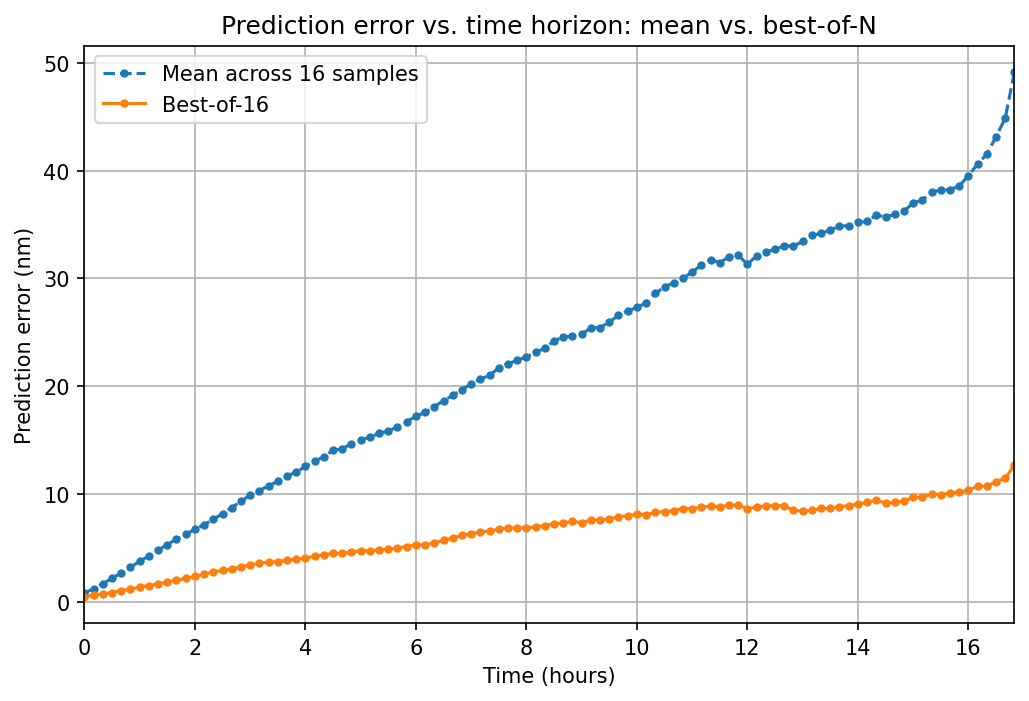

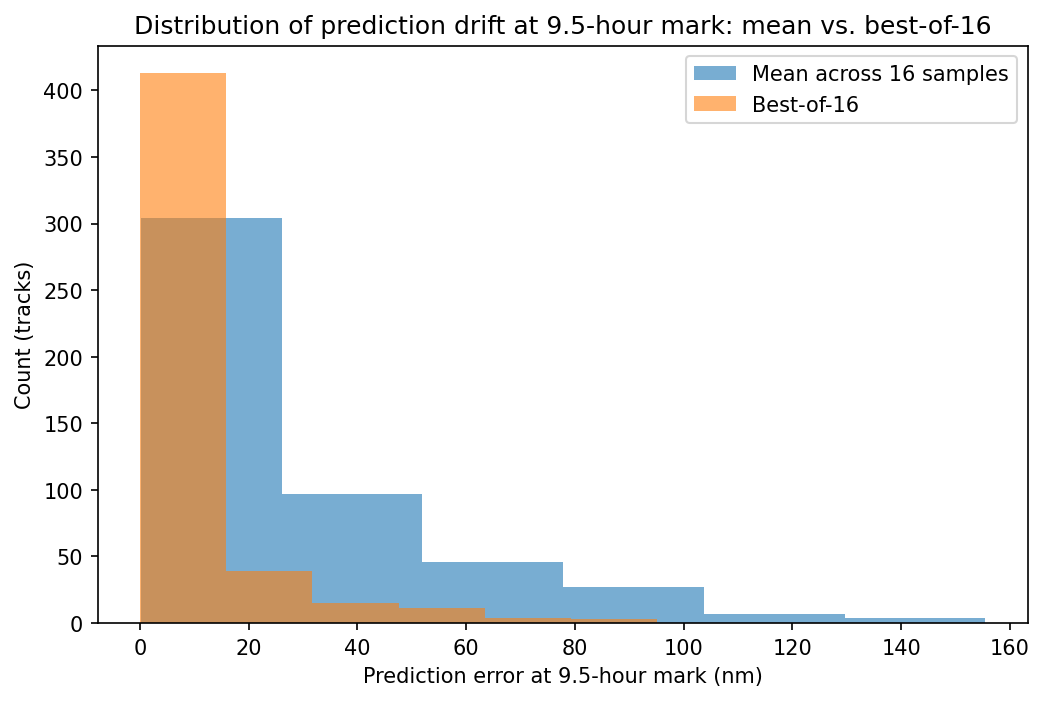

In [11]:
# if testing was stopped early mentoined that as it will afect conclutoins
pct = 100 * n_tracks_completed / total_tracks
if time_limit_hit:
    print(f"\nPARTIAL RUN: stopped after time limit.")
else:
    print(f"\nFull test set completed.")
print(f"Tracks evaluated: {n_tracks_completed} of {total_tracks} ({pct:.1f}%)")
print(f"Batches evaluated: {n_batches_completed} of {len(aisdls['test'])}")
print(f"Elapsed time: {(time.time() - start_time)/3600:.2f} hours")

# print sumarry stats
min_errors = torch.cat(l_min_errors, dim=0)
mean_errors = torch.cat(l_mean_errors, dim=0)
masks_all = torch.cat(l_masks, dim=0)

overall_mean = (mean_errors * masks_all).sum().item() / masks_all.sum().item()
overall_min = (min_errors * masks_all).sum().item() / masks_all.sum().item()

print(f"\nMean displacement error (nm): {overall_mean:.3f}")
print(f"Min (best-of-{n_samples_eval}) displacement error (nm): {overall_min:.3f}")
print(f"Average time per sample generation: {sum(sample_times)/len(sample_times):.1f} sec ({len(sample_times)} samples total)")

# Plot 1: mean vs. best-of-N error over time horizon
horizon_hours = np.arange(horizon_len) / 6  # 6 timesteps = 1 hour

min_error_per_step = ((min_errors * masks_all).sum(dim=0) / masks_all.sum(dim=0)).cpu().numpy()
mean_error_per_step = (horizon_error_sum / horizon_mask_sum).numpy()

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(horizon_hours, mean_error_per_step, label=f"Mean across {n_samples_eval} samples", linestyle="--", marker='o', markersize=3)
plt.plot(horizon_hours, min_error_per_step, label=f"Best-of-{n_samples_eval}", marker='o', markersize=3)
plt.xlabel("Time (hours)")
plt.ylabel("Prediction error (nm)")
plt.title("Prediction error vs. time horizon: mean vs. best-of-N")
plt.xlim([0, horizon_hours[-1]])
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: histogram, mean vs. best-of-N final-step drift (nm)
min_coverage = 0.5  
coverage_ok = (horizon_mask_sum >= min_coverage * n_tracks_completed).nonzero()
final_step = int(coverage_ok.max()) if len(coverage_ok) > 0 else int(horizon_mask_sum.nonzero().max())
final_step_hours = horizon_hours[final_step]

final_mask = masks_all[:, final_step].bool()
final_mean_per_track = mean_errors[:, final_step][final_mask].cpu().numpy()
final_min_per_track = min_errors[:, final_step][final_mask].cpu().numpy()

plt.figure(figsize=(8, 5), dpi=150)
plt.hist(final_mean_per_track, bins=6, alpha=0.6, label=f"Mean across {n_samples_eval} samples")
plt.hist(final_min_per_track, bins=6, alpha=0.6, label=f"Best-of-{n_samples_eval}")
plt.xlabel(f"Prediction error at {final_step_hours:.2g}-hour mark (nm)")
plt.ylabel("Count (tracks)")
plt.title(f"Distribution of prediction drift at {final_step_hours:.2g}-hour mark: mean vs. best-of-{n_samples_eval}")
plt.legend()
plt.show()


Found 1079 paths
Using 0th index


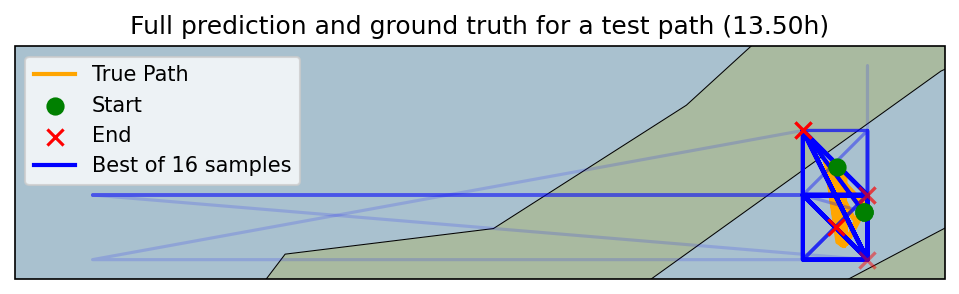

Found 1079 paths
Using 1th index


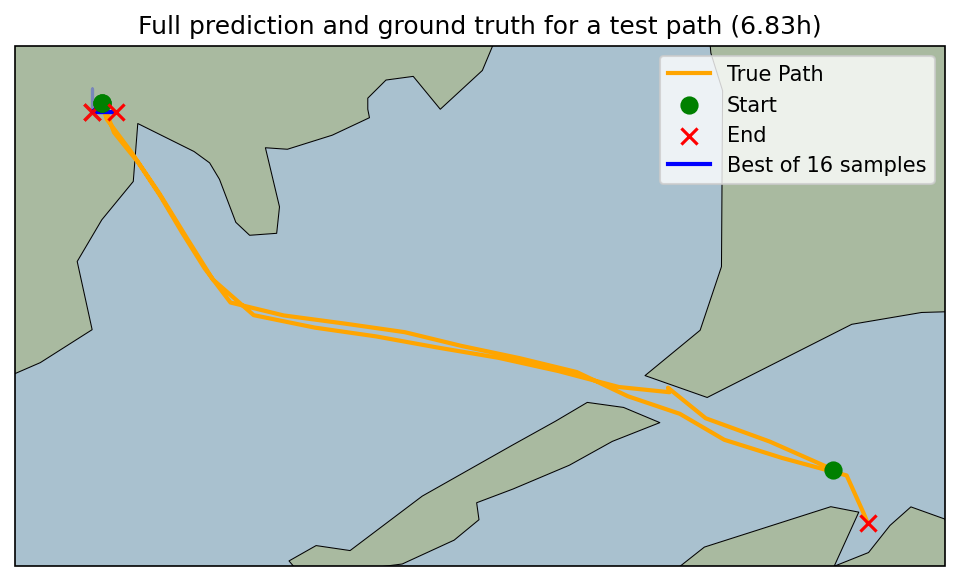

Found 1079 paths
Using 2th index


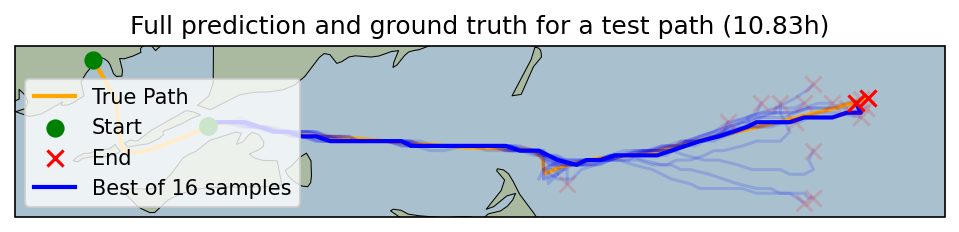

Found 1079 paths
Using 3th index


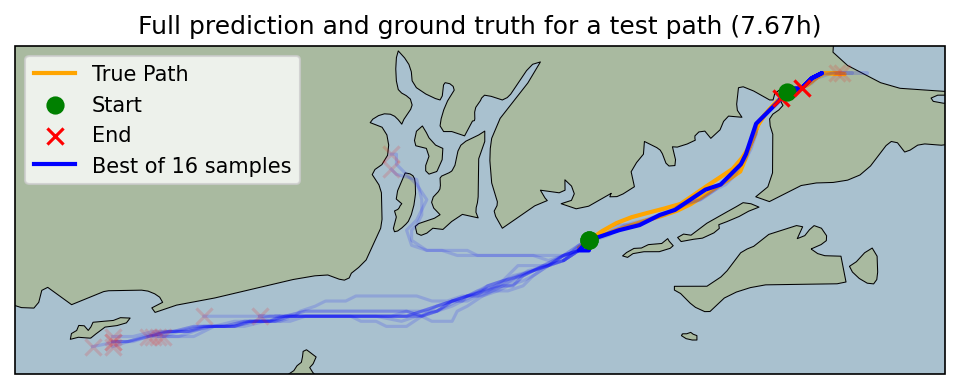

Found 1079 paths
Using 4th index


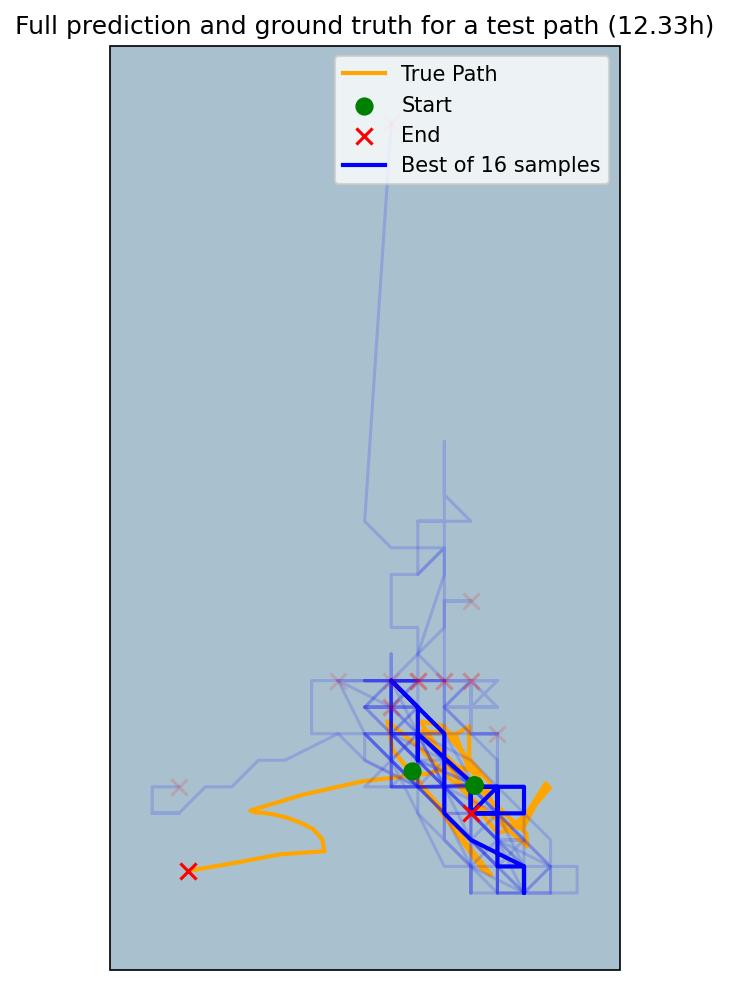

In [ ]:
# plot the perdictoin of the test paths
def makePathPlot(idx=0, hour=20, tol=2, samp=16, iPlot=-1):
    def toLatLong(normTraj):
        lat = normTraj[..., 0] * model.lat_range + model.lat_min
        lon = normTraj[..., 1] * model.lon_range + model.lon_min
        return lat, lon

    tracks = [
        i for i, v in enumerate(Data["test"])
        if abs(len(v["traj"]) * resampleMin / 60 - hour) <= tol
    ]
    print(f"Found {len(tracks)} paths")
    if iPlot != -1:
        print(f"Using {idx}th index")
    else:
        print(f"Using {idx}th index for the {iPlot}th plot")

    if idx >= len(tracks):
        print(f"Only {len(tracks)} paths near {hour}h found, skipping idx {idx}")
        return

    track = tracks[idx]
    v = Data["test"][track]

    seq = torch.tensor(v["traj"][:, :4], dtype=torch.float32).unsqueeze(0).to(cf.device)
    seqInt = seq[:, :cf.init_seqlen, :]
    fullLen = seq.shape[1]
    horizonLen = fullLen - cf.init_seqlen

    Vrange = torch.tensor([model.lat_range, model.lon_range, model.sog_range, 360.0]).to(cf.device)
    VroiMin = torch.tensor([model.lat_min, model.lon_min, 0.0, 0.0]).to(cf.device)

    model.eval()
    allPerds = []
    with torch.no_grad():
        for _ in range(samp):
            preds = trainers.sample(model, seqInt, horizonLen, temperature=1.0, sample=True,
                                    sample_mode=cf.sample_mode, r_vicinity=cf.r_vicinity, top_k=cf.top_k)
            allPerds.append(preds)

    trueLat, trueLon = toLatLong(seq[0].cpu())

    predPath, errors = [], []
    for preds in allPerds:
        lat, lon = toLatLong(preds[0].cpu())
        predPath.append((lat, lon))
        inputCords = (seq * Vrange + VroiMin) * torch.pi / 180
        predCords = (preds * Vrange + VroiMin) * torch.pi / 180
        d = utils.haversine(inputCords, predCords)[0, cf.init_seqlen:]
        errors.append(d.mean().item())

    best_i = int(np.argmin(errors))

    plt.figure(figsize=(8, 8), dpi=150)
    ax = plt.axes(projection=ccrs.PlateCarree())
    land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor="#a9baa0")
    ocean_10m = cfeature.NaturalEarthFeature('physical', 'ocean', '10m', facecolor="#a9c1cf")
    coast_10m = cfeature.NaturalEarthFeature('physical', 'coastline', '10m', facecolor='none', edgecolor='black', linewidth=0.5)
    ax.add_feature(land_10m, zorder=0)
    ax.add_feature(ocean_10m, zorder=0)
    ax.add_feature(coast_10m, zorder=1)

    allLats = torch.cat([trueLat] + [lat for lat, lon in predPath])
    allLons = torch.cat([trueLon] + [lon for lat, lon in predPath])
    rangLat = allLats.max() - allLats.min()
    rangLong = allLons.max() - allLons.min()
    pad = 0.1
    ax.set_extent([
        (allLons.min() - pad*rangLong).item(), (allLons.max() + pad*rangLong).item(),
        (allLats.min() - pad*rangLat).item(), (allLats.max() + pad*rangLat).item(),
    ], crs=ccrs.PlateCarree())

    plt.plot(trueLon, trueLat, color="orange", linewidth=2, label="True Path")
    plt.scatter(trueLon[0], trueLat[0], color="green", marker="o", s=60, zorder=5, label="Start")
    plt.scatter(trueLon[-1], trueLat[-1], color="red", marker="x", s=60, zorder=5, label="End")

    for i, (lat, lon) in enumerate(predPath):
        if i == best_i:
            continue
        plt.plot(lon[cf.init_seqlen-1:], lat[cf.init_seqlen-1:], color="blue", alpha=0.15)
        plt.scatter(lon[cf.init_seqlen-1], lat[cf.init_seqlen-1], color="green", marker="o", s=60, zorder=4, alpha=0.15)
        plt.scatter(lon[-1], lat[-1], color="red", marker="x", s=60, zorder=4, alpha=0.15)

    bestLat, bestLong = predPath[best_i]
    plt.plot(bestLong[cf.init_seqlen-1:], bestLat[cf.init_seqlen-1:], color="blue",
            alpha=1, linewidth=2, label=f"Best of {samp} samples")
    plt.scatter(bestLong[cf.init_seqlen-1], bestLat[cf.init_seqlen-1], color="green", marker="o", s=60, zorder=4)
    plt.scatter(bestLong[-1], bestLat[-1], color="red", marker="x", s=60, zorder=4)

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Full prediction and ground truth for a test path ({fullLen*resampleMin/60:.2f}h)")
    plt.legend()
    plt.show()

# set the loop to chose how many to reneder
for i in range(0, 5):
    makePathPlot(idx=i, hour=10, tol=5, iPlot=i)


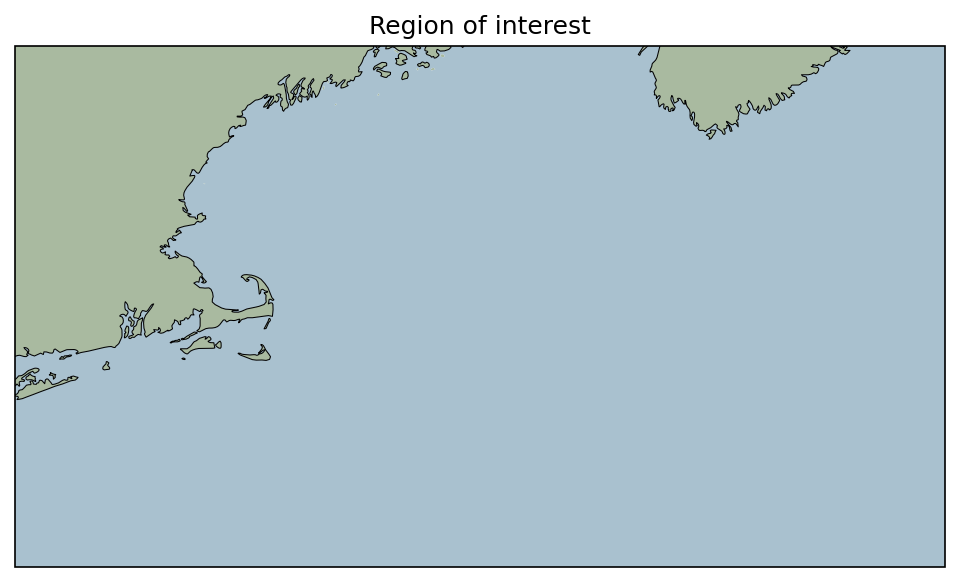

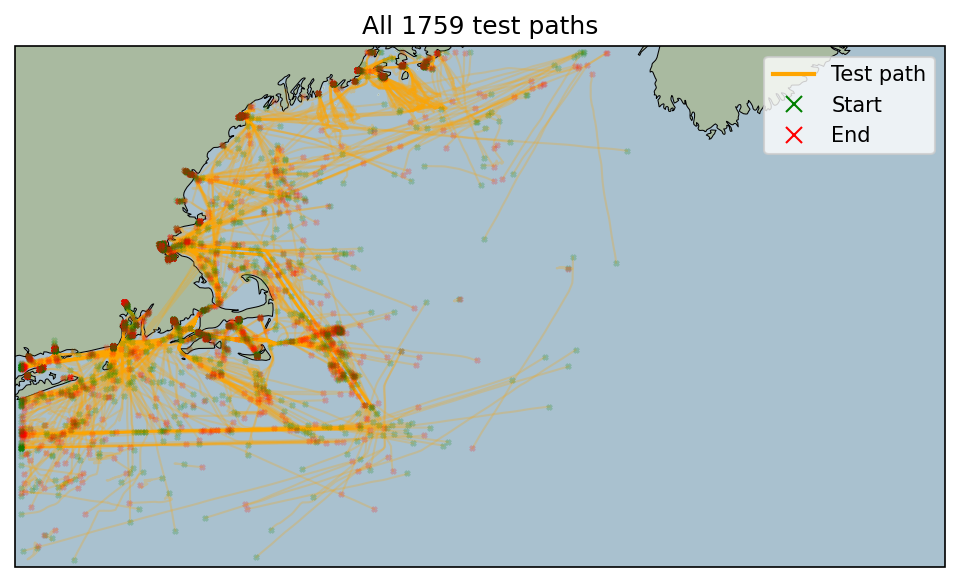

In [13]:
# Plot the whole area then the whole area with all test paths
def makeOverviewPlots():
    def toLatLong(normTraj):
        lat = normTraj[..., 0] * model.lat_range + model.lat_min
        lon = normTraj[..., 1] * model.lon_range + model.lon_min
        return lat, lon

    def newCoastAx():
        plt.figure(figsize=(8, 8), dpi=150)
        ax = plt.axes(projection=ccrs.PlateCarree())
        land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor="#a9baa0")
        ocean_10m = cfeature.NaturalEarthFeature('physical', 'ocean', '10m', facecolor="#a9c1cf")
        coast_10m = cfeature.NaturalEarthFeature('physical', 'coastline', '10m', facecolor='none', edgecolor='black', linewidth=0.5)
        ax.add_feature(land_10m, zorder=0)
        ax.add_feature(ocean_10m, zorder=0)
        ax.add_feature(coast_10m, zorder=1)
        ax.set_extent([model.lon_min, model.lon_max, model.lat_min, model.lat_max], crs=ccrs.PlateCarree())
        return ax

    ax1 = newCoastAx()
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")
    ax1.set_title("Region of interest")
    plt.show()

    ax2 = newCoastAx()
    for v in Data["test"]:
        traj = torch.tensor(v["traj"][:, :4], dtype=torch.float32)
        lat, lon = toLatLong(traj)
        ax2.plot(lon, lat, color="orange", alpha=0.25, linewidth=1, transform=ccrs.PlateCarree(), zorder=3)
        ax2.scatter(lon[0], lat[0], color="green", marker="x", s=5, alpha=0.2, zorder=4, transform=ccrs.PlateCarree())
        ax2.scatter(lon[-1], lat[-1], color="red", marker="x", s=5, alpha=0.2, zorder=4, transform=ccrs.PlateCarree())

    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")
    ax2.set_title(f"All {len(Data['test'])} test paths")
    legendElms = [
        Line2D([0], [0], color="orange", lw=2, label="Test path"),
        Line2D([0], [0], marker="x", linestyle="None", markerfacecolor="green", markeredgecolor="green", markersize=8, label="Start"),
        Line2D([0], [0], marker="x", linestyle="None", color="red", markersize=8, label="End"),
    ]
    ax2.legend(handles=legendElms)
    plt.show()

makeOverviewPlots()
